## Import Necessary libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

%matplotlib inline

## Loading data

In [2]:
data = pd.read_csv(r'../3_Data/processed/f_2025_hourly_all_selected_features_standardized.csv')
data.head()

,timestamp_quarter,timestamp_second,timestamp_hour,timestamp_year_end,passenger_demand_lag_1,passenger_demand_lag_8,taxi_demand_lag_16,timestamp_days_in_month,timestamp_day_of_month,timestamp_month_start,timestamp_year_start,timestamp_leap_year,timestamp_month_end,timestamp_day_of_week,timestamp_minute,taxi_demand_expanding_std,timestamp_quarter_start,timestamp_year,taxi_demand
0,-1.239506,0.0,-1.661325,0.0,-0.956018,0.384374,-1.421891,0.694623,-1.570278,-0.174078,0.0,0.0,-0.184988,-0.001836,0.0,-5.062041,-0.086066,0.0,1051
1,-1.239506,0.0,-1.516862,0.0,-1.277794,0.427059,-1.288108,0.694623,-1.570278,-0.174078,0.0,0.0,-0.184988,-0.001836,0.0,-4.908923,-0.086066,0.0,436
2,-1.239506,0.0,-1.372399,0.0,-1.524301,0.239997,-1.037265,0.694623,-1.570278,-0.174078,0.0,0.0,-0.184988,-0.001836,0.0,-4.628398,-0.086066,0.0,268
3,-1.239506,0.0,-1.227936,0.0,-1.606783,-0.014859,-0.729367,0.694623,-1.570278,-0.174078,0.0,0.0,-0.184988,-0.001836,0.0,-4.362462,-0.086066,0.0,220
4,-1.239506,0.0,-1.083473,0.0,-1.604274,-0.196585,-0.447701,0.694623,-1.570278,-0.174078,0.0,0.0,-0.184988,-0.001836,0.0,-4.140598,-0.086066,0.0,277


In [3]:
data.head().T

,0,1,2,3,4
timestamp_quarter,-1.239506,-1.239506,-1.239506,-1.239506,-1.239506
timestamp_second,0.000000,0.000000,0.000000,0.000000,0.000000
timestamp_hour,-1.661325,-1.516862,-1.372399,-1.227936,-1.083473
timestamp_year_end,0.000000,0.000000,0.000000,0.000000,0.000000
passenger_demand_lag_1,-0.956018,-1.277794,-1.524301,-1.606783,-1.604274
passenger_demand_lag_8,0.384374,0.427059,0.239997,-0.014859,-0.196585
taxi_demand_lag_16,-1.421891,-1.288108,-1.037265,-0.729367,-0.447701
timestamp_days_in_month,0.694623,0.694623,0.694623,0.694623,0.694623
timestamp_day_of_month,-1.570278,-1.570278,-1.570278,-1.570278,-1.570278
timestamp_month_start,-0.174078,-0.174078,-0.174078,-0.174078,-0.174078


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6528 entries, 0 to 6527
Data columns (total 19 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   timestamp_quarter          6528 non-null   float64
 1   timestamp_second           6528 non-null   float64
 2   timestamp_hour             6528 non-null   float64
 3   timestamp_year_end         6528 non-null   float64
 4   passenger_demand_lag_1     6528 non-null   float64
 5   passenger_demand_lag_8     6528 non-null   float64
 6   taxi_demand_lag_16         6528 non-null   float64
 7   timestamp_days_in_month    6528 non-null   float64
 8   timestamp_day_of_month     6528 non-null   float64
 9   timestamp_month_start      6528 non-null   float64
 10  timestamp_year_start       6528 non-null   float64
 11  timestamp_leap_year        6528 non-null   float64
 12  timestamp_month_end        6528 non-null   float64
 13  timestamp_day_of_week      6528 non-null   float

In [5]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
timestamp_quarter,6528.0,-2.786442e-16,1.000077,-1.239506,-1.239506,-0.013522,1.212462,1.212462
timestamp_second,6528.0,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
timestamp_hour,6528.0,-4.353816e-18,1.000077,-1.661325,-0.830662,0.000000,0.830662,1.661325
timestamp_year_end,6528.0,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
passenger_demand_lag_1,6528.0,-2.394599e-17,1.000077,-1.699302,-1.003688,0.197014,0.798541,2.353635
passenger_demand_lag_8,6528.0,-1.240837e-16,1.000077,-1.699357,-1.003211,0.197469,0.798044,2.356683
taxi_demand_lag_16,6528.0,1.023147e-16,1.000077,-1.787827,-0.938403,0.184161,0.696258,2.815555
timestamp_days_in_month,6528.0,9.404242e-16,1.000077,-2.562920,-0.391225,0.694623,0.694623,0.694623
timestamp_day_of_month,6528.0,9.578395e-17,1.000077,-1.684602,-0.884332,0.030262,0.830532,1.745127
timestamp_month_start,6528.0,0.000000e+00,1.000077,-0.174078,-0.174078,-0.174078,-0.174078,5.744563


In [6]:
data.shape

(6528, 19)

In [7]:
df = data.copy()

### Principal Component Analysis (PCA)

In [8]:
reducer = PCA(
    n_components=19,
    copy=True,
    whiten=False,
    svd_solver='auto',
    tol=0.0,
    iterated_power='auto',
    n_oversamples=10,
    power_iteration_normalizer='auto',
    random_state=33
)
reducer

,n_components,19
,copy,True
,whiten,False
,svd_solver,'auto'
,tol,0.0
,iterated_power,'auto'
,n_oversamples,10
,power_iteration_normalizer,'auto'
,random_state,33


In [9]:
# Extract features and target variable
features = df.drop(columns=['taxi_demand'])
target = df['taxi_demand']

# Perform PCA for dimensionality reduction
pca = PCA(n_components=0.95, random_state=33)
X_pca = pca.fit_transform(features)

print("Original shape:", features.shape)
print("Reduced shape:", X_pca.shape)

Original shape: (6528, 18)
Reduced shape: (6528, 10)


In [10]:
print("Number of components chosen:", X_pca.shape[1])
explained_var = np.cumsum(pca.explained_variance_ratio_)
print("Cumulative variance explained:", explained_var)

Number of components chosen: 10
Cumulative variance explained: [0.18150869 0.32291976 0.45661969 0.56725749 0.66538982 0.75427901
 0.83611978 0.89234146 0.93196618 0.96716149]


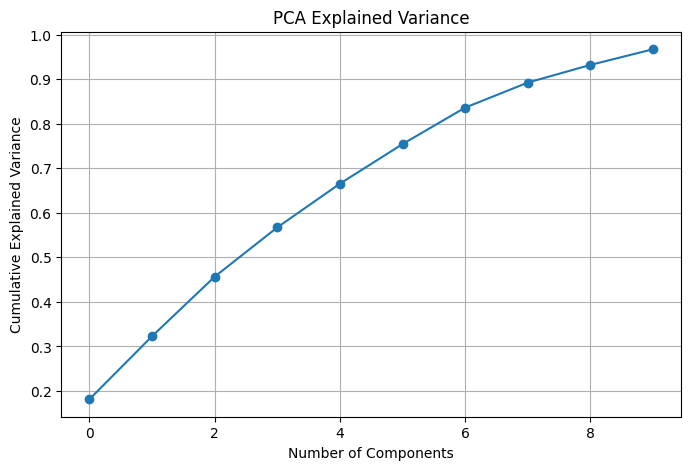

In [11]:
plt.figure(figsize=(8,5))
plt.plot(np.cumsum(pca.explained_variance_ratio_), marker='o')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA Explained Variance')
plt.grid(True)
plt.show()


Let's combine reduced features with the target variable for plotting

In [12]:

# reduced_df = pd.DataFrame({'PC1': X_pca[:, 0],
#                            'PC2': X_pca[:, 1],
#                            continued...,     
#                            'taxi_demand': target})
# reduced_df.head()

# OR 

# X_pca is our PCA-transformed array (10 components)
# target is taxi_demand

reduced_df = pd.DataFrame(
    X_pca, 
    columns=[f'PC{i+1}' for i in range(X_pca.shape[1])]
)
# Add target column
reduced_df['taxi_demand'] = target.values

reduced_df.head()

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,taxi_demand
0,-0.518754,0.917431,-4.289254,1.130338,-0.421782,-1.711911,2.613329,-1.037458,-1.132565,1.374478,1051
1,-0.699536,0.915800,-4.206067,1.155734,-0.421137,-1.694405,2.545232,-1.031434,-1.098232,1.314072,436
2,-0.896397,0.911873,-4.015032,0.924829,-0.424154,-1.656173,2.435000,-1.014045,-1.031267,1.189971,268
3,-1.022439,0.904980,-3.811575,0.575039,-0.437192,-1.594720,2.337239,-0.991172,-0.964198,1.051892,220
4,-1.084073,0.895503,-3.635308,0.278344,-0.456338,-1.521287,2.255461,-0.967715,-0.905209,0.920323,277


In [13]:
reduced_df.head().T

,0,1,2,3,4
PC1,-0.518754,-0.699536,-0.896397,-1.022439,-1.084073
PC2,0.917431,0.915800,0.911873,0.904980,0.895503
PC3,-4.289254,-4.206067,-4.015032,-3.811575,-3.635308
PC4,1.130338,1.155734,0.924829,0.575039,0.278344
PC5,-0.421782,-0.421137,-0.424154,-0.437192,-0.456338
PC6,-1.711911,-1.694405,-1.656173,-1.594720,-1.521287
PC7,2.613329,2.545232,2.435000,2.337239,2.255461
PC8,-1.037458,-1.031434,-1.014045,-0.991172,-0.967715
PC9,-1.132565,-1.098232,-1.031267,-0.964198,-0.905209
PC10,1.374478,1.314072,1.189971,1.051892,0.920323


In [14]:
reduced_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6528 entries, 0 to 6527
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PC1          6528 non-null   float64
 1   PC2          6528 non-null   float64
 2   PC3          6528 non-null   float64
 3   PC4          6528 non-null   float64
 4   PC5          6528 non-null   float64
 5   PC6          6528 non-null   float64
 6   PC7          6528 non-null   float64
 7   PC8          6528 non-null   float64
 8   PC9          6528 non-null   float64
 9   PC10         6528 non-null   float64
 10  taxi_demand  6528 non-null   int64  
dtypes: float64(10), int64(1)
memory usage: 561.1 KB


In [15]:
reduced_df.describe().T

,count,mean,std,min,25%,50%,75%,max
PC1,6528.0,3.483053e-17,1.475953,-2.374069,-1.420409,-0.235084,1.484455,2.839960
PC2,6528.0,4.789197e-17,1.302764,-2.670925,-0.538714,-0.101052,0.332921,10.900077
PC3,6528.0,6.966105e-17,1.266746,-4.289254,-0.591518,0.298114,0.949155,3.565753
PC4,6528.0,4.789197e-17,1.152327,-2.648014,-1.095533,0.395882,0.924121,2.226494
PC5,6528.0,-8.707632e-18,1.085250,-1.726561,-0.611503,-0.154243,0.303161,5.315075
PC6,6528.0,-1.741526e-17,1.032876,-2.665217,-0.814528,0.020241,0.771581,3.136135
PC7,6528.0,8.707632e-18,0.991080,-2.414787,-0.602978,-0.012668,0.560655,2.895650
PC8,6528.0,-4.353816e-17,0.821440,-2.569211,-0.547966,0.025607,0.586213,3.248706
PC9,6528.0,0.000000e+00,0.689615,-3.225820,-0.322009,-0.062457,0.227428,3.877231
PC10,6528.0,0.000000e+00,0.649930,-1.621150,-0.497328,0.066693,0.426806,2.283508


In [16]:
reduced_df.shape

(6528, 11)

### **Let's Save The Data**

In [17]:
reduced_df.to_csv(r'../3_Data/processed/g_2025_hourly_all_PCA_reduced.csv', index=False)

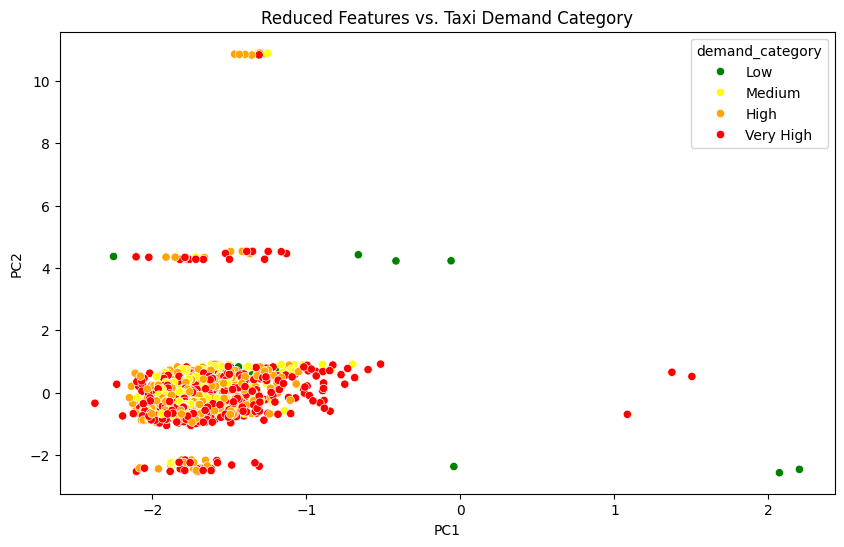

In [18]:
bins = [0, 200, 500, 1000, 2000]
labels = ['Low','Medium','High','Very High']
reduced_df['demand_category'] = pd.cut(reduced_df['taxi_demand'], bins=bins, labels=labels)

plt.figure(figsize=(10,6))
sns.scatterplot(
    x='PC1', 
    y='PC2', 
    data=reduced_df, 
    hue='demand_category',
    palette=['green','yellow','orange','red']
)
plt.title('Reduced Features vs. Taxi Demand Category')
plt.show()


In [19]:
reduced_df.head()

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,taxi_demand,demand_category
0,-0.518754,0.917431,-4.289254,1.130338,-0.421782,-1.711911,2.613329,-1.037458,-1.132565,1.374478,1051,Very High
1,-0.699536,0.915800,-4.206067,1.155734,-0.421137,-1.694405,2.545232,-1.031434,-1.098232,1.314072,436,Medium
2,-0.896397,0.911873,-4.015032,0.924829,-0.424154,-1.656173,2.435000,-1.014045,-1.031267,1.189971,268,Medium
3,-1.022439,0.904980,-3.811575,0.575039,-0.437192,-1.594720,2.337239,-0.991172,-0.964198,1.051892,220,Medium
4,-1.084073,0.895503,-3.635308,0.278344,-0.456338,-1.521287,2.255461,-0.967715,-0.905209,0.920323,277,Medium


In [20]:
reduced_df.head().T

,0,1,2,3,4
PC1,-0.518754,-0.699536,-0.896397,-1.022439,-1.084073
PC2,0.917431,0.9158,0.911873,0.90498,0.895503
PC3,-4.289254,-4.206067,-4.015032,-3.811575,-3.635308
PC4,1.130338,1.155734,0.924829,0.575039,0.278344
PC5,-0.421782,-0.421137,-0.424154,-0.437192,-0.456338
PC6,-1.711911,-1.694405,-1.656173,-1.59472,-1.521287
PC7,2.613329,2.545232,2.435,2.337239,2.255461
PC8,-1.037458,-1.031434,-1.014045,-0.991172,-0.967715
PC9,-1.132565,-1.098232,-1.031267,-0.964198,-0.905209
PC10,1.374478,1.314072,1.189971,1.051892,0.920323


In [21]:
reduced_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6528 entries, 0 to 6527
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype   
---  ------           --------------  -----   
 0   PC1              6528 non-null   float64 
 1   PC2              6528 non-null   float64 
 2   PC3              6528 non-null   float64 
 3   PC4              6528 non-null   float64 
 4   PC5              6528 non-null   float64 
 5   PC6              6528 non-null   float64 
 6   PC7              6528 non-null   float64 
 7   PC8              6528 non-null   float64 
 8   PC9              6528 non-null   float64 
 9   PC10             6528 non-null   float64 
 10  taxi_demand      6528 non-null   int64   
 11  demand_category  1313 non-null   category
dtypes: category(1), float64(10), int64(1)
memory usage: 567.7 KB


In [22]:
reduced_df.describe().T

,count,mean,std,min,25%,50%,75%,max
PC1,6528.0,3.483053e-17,1.475953,-2.374069,-1.420409,-0.235084,1.484455,2.839960
PC2,6528.0,4.789197e-17,1.302764,-2.670925,-0.538714,-0.101052,0.332921,10.900077
PC3,6528.0,6.966105e-17,1.266746,-4.289254,-0.591518,0.298114,0.949155,3.565753
PC4,6528.0,4.789197e-17,1.152327,-2.648014,-1.095533,0.395882,0.924121,2.226494
PC5,6528.0,-8.707632e-18,1.085250,-1.726561,-0.611503,-0.154243,0.303161,5.315075
PC6,6528.0,-1.741526e-17,1.032876,-2.665217,-0.814528,0.020241,0.771581,3.136135
PC7,6528.0,8.707632e-18,0.991080,-2.414787,-0.602978,-0.012668,0.560655,2.895650
PC8,6528.0,-4.353816e-17,0.821440,-2.569211,-0.547966,0.025607,0.586213,3.248706
PC9,6528.0,0.000000e+00,0.689615,-3.225820,-0.322009,-0.062457,0.227428,3.877231
PC10,6528.0,0.000000e+00,0.649930,-1.621150,-0.497328,0.066693,0.426806,2.283508


In [23]:
reduced_df.shape

(6528, 12)

## T-distributed Stochastic Neighbor Embedding.(TSNE)

In [24]:
tsne = TSNE(
    n_components=2,         # 2D for plotting
    perplexity=30,          # typical values: 5-50
    early_exaggeration=12,
    learning_rate='auto',   # automatic
    max_iter=1000,          # use max_iter instead of n_iter
    n_iter_without_progress=300,
    min_grad_norm=1e-7,
    metric='euclidean',
    init='pca',             # better convergence than random
    verbose=1,
    random_state=33,
    method='barnes_hut',    # good for medium-large datasets
    angle=0.5
)
tsne


,n_components,2
,perplexity,30
,early_exaggeration,12
,learning_rate,'auto'
,max_iter,1000
,n_iter_without_progress,300
,min_grad_norm,1e-07
,metric,'euclidean'
,metric_params,None
,init,'pca'
,verbose,1


In [25]:
# Fit TSNE on PCA-reduced data
X_tsne = tsne.fit_transform(X_pca)

print("Original shape:", X_pca.shape)
print("TSNE shape:", X_tsne.shape)

[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 6528 samples in 0.018s...
[t-SNE] Computed neighbors for 6528 samples in 0.910s...
[t-SNE] Computed conditional probabilities for sample 1000 / 6528
[t-SNE] Computed conditional probabilities for sample 2000 / 6528
[t-SNE] Computed conditional probabilities for sample 3000 / 6528
[t-SNE] Computed conditional probabilities for sample 4000 / 6528
[t-SNE] Computed conditional probabilities for sample 5000 / 6528
[t-SNE] Computed conditional probabilities for sample 6000 / 6528
[t-SNE] Computed conditional probabilities for sample 6528 / 6528
[t-SNE] Mean sigma: 0.561954
[t-SNE] KL divergence after 250 iterations with early exaggeration: 69.205299
[t-SNE] KL divergence after 1000 iterations: 0.849133
Original shape: (6528, 10)
TSNE shape: (6528, 2)


Let's create a DataFrame for TSNE visualization

In [26]:
# Assuming TSNE output is X_tsne and target is 'taxi_demand'
tsne_df = pd.DataFrame({
    'TSNE1': X_tsne[:, 0],   # first TSNE component
    'TSNE2': X_tsne[:, 1],   # second TSNE component
    'taxi_demand': target.values  # original taxi demand values
})

# Check the first rows
tsne_df.head()


,TSNE1,TSNE2,taxi_demand
0,63.202065,42.844177,1051
1,63.240654,42.800079,436
2,63.415771,42.530827,268
3,63.898384,42.050129,220
4,64.463890,41.729771,277


In [27]:
tsne_df = pd.DataFrame(
    X_tsne,
    columns=['TSNE1', 'TSNE2']
)
tsne_df['taxi_demand'] = target.values
tsne_df.head()

,TSNE1,TSNE2,taxi_demand
0,63.202065,42.844177,1051
1,63.240654,42.800079,436
2,63.415771,42.530827,268
3,63.898384,42.050129,220
4,64.463890,41.729771,277


In [28]:
tsne_df.shape

(6528, 3)

In [29]:
tsne_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6528 entries, 0 to 6527
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   TSNE1        6528 non-null   float32
 1   TSNE2        6528 non-null   float32
 2   taxi_demand  6528 non-null   int64  
dtypes: float32(2), int64(1)
memory usage: 102.1 KB


In [30]:
tsne_df.columns

Index(['TSNE1', 'TSNE2', 'taxi_demand'], dtype='object')

### **Plot t-SNE Scatter with Categories**

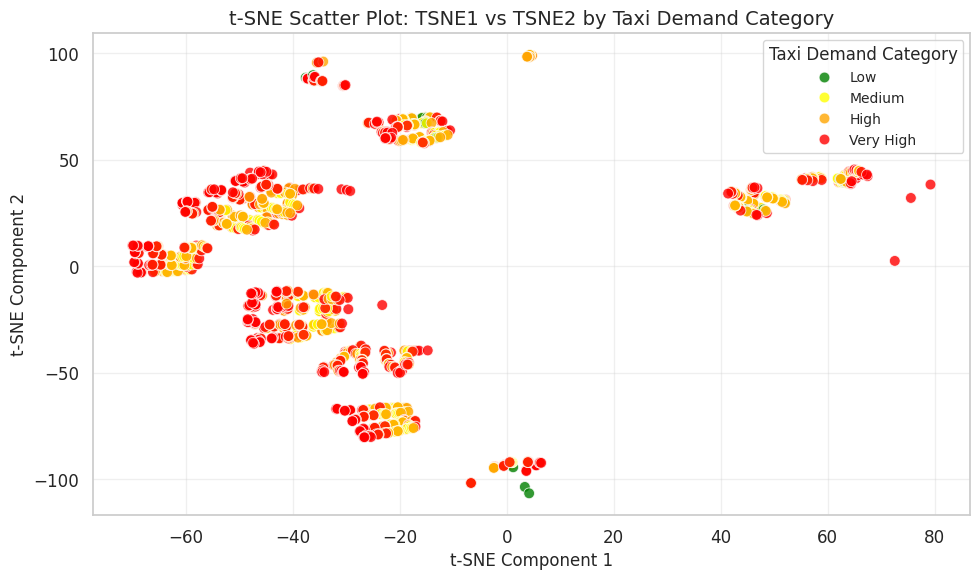

In [31]:
# Create categories for taxi demand
bins = [0, 200, 500, 1000, 2000]  # adjust based on your data range
labels = ['Low', 'Medium', 'High', 'Very High']
tsne_df['demand_category'] = pd.cut(tsne_df['taxi_demand'], bins=bins, labels=labels)

# Set style
sns.set(style="whitegrid", palette="muted", font_scale=1.1)

plt.figure(figsize=(10,6))

# Scatter plot
sns.scatterplot(
    x='TSNE1',
    y='TSNE2',
    data=tsne_df,
    hue='demand_category',
    palette=['green', 'yellow', 'orange', 'red'],
    s=60,
    alpha=0.8
)

# Titles and labels
plt.title('t-SNE Scatter Plot: TSNE1 vs TSNE2 by Taxi Demand Category', fontsize=14)
plt.xlabel('t-SNE Component 1', fontsize=12)
plt.ylabel('t-SNE Component 2', fontsize=12)

# Legend
plt.legend(title='Taxi Demand Category', fontsize=10, title_fontsize=12)

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [32]:
tsne_df.head()

,TSNE1,TSNE2,taxi_demand,demand_category
0,63.202065,42.844177,1051,Very High
1,63.240654,42.800079,436,Medium
2,63.415771,42.530827,268,Medium
3,63.898384,42.050129,220,Medium
4,64.463890,41.729771,277,Medium


In [33]:
tsne_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6528 entries, 0 to 6527
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype   
---  ------           --------------  -----   
 0   TSNE1            6528 non-null   float32 
 1   TSNE2            6528 non-null   float32 
 2   taxi_demand      6528 non-null   int64   
 3   demand_category  1313 non-null   category
dtypes: category(1), float32(2), int64(1)
memory usage: 108.7 KB


In [34]:
tsne_df.describe().T

,count,mean,std,min,25%,50%,75%,max
TSNE1,6528.0,0.276262,35.013912,-72.848534,-26.103013,-0.044691,24.323971,79.582092
TSNE2,6528.0,-0.597116,46.422913,-108.533195,-33.548311,2.401241,32.034920,101.137260
taxi_demand,6528.0,5463.428615,3051.456804,0.000000,2596.000000,6033.000000,7587.250000,14039.000000


In [35]:
tsne_df.shape

(6528, 4)

## Extract Pipeline for Dimensionality Reduction Data

In [ ]:
def ReduceDimensionality():
    # Extract features and target variable
    features = df.drop(columns=['taxi_demand'])
    target = df['taxi_demand']

    # Perform PCA for dimensionality reduction
    pca = PCA(n_components=0.95, random_state=33)
    X_pca = pca.fit_transform(features)

    print("Original shape:", features.shape)    
    print("Reduced shape:", X_pca.shape)

    # X_pca is our PCA-transformed array (10 components)
    # target is taxi_demand

    reduced_df = pd.DataFrame(
        X_pca, 
        columns=[f'PC{i+1}' for i in range(X_pca.shape[1])]
    )
    # Add target column
    reduced_df['taxi_demand'] = target.values
    print(reduced_df.head())
    return reduced_df

## **Q/A**

### **What is Dimensionality Reduction?**
Dimensionality Reduction means:
Reducing the number of input features (columns) while keeping as much important information as possible.
So instead of:
```bash
19 features → maybe reduce to 5 or 8 features
```
Reduce number of features
#### **Why we do this:**
- Reduce model complexity </br>
- Prevent overfitting </br>
- Improve training speed </br>
- Remove redundant / correlated features </br>
- Better visualization (2D / 3D)

#### **Simple analogy:**
Imagine describing a person with:
- height, weight, BMI, waist, chest, body-fat %, muscle mass...</br>

Many of these contain **overlapping information**. </br>
Dimensionality reduction keeps only the essential ones.

#### **What is PCA (Principal Component Analysis)?**
PCA is a mathematical technique that:</br>

- Finds new axes (directions) in data</br>
- These axes capture maximum variance</br>
- Projects data onto fewer dimensions</br>
- Keeps most of the information</br>

**Key idea:**</br>

PCA does NOT remove rows</br>
PCA transforms your 19 columns into **new compressed columns**</br>
These new columns are called:</br>
```bash
Principal Components (PC1, PC2, PC3...)
```

####  **How PCA Works (Conceptually)**

Step-by-step:

1. Standardize data (already we did this)
2. PCA finds directions where variance is maximum
3. First direction = PC1 (most important)
4. Second = PC2 (next important)
5. And so on...

Visually:
```bash
Original space (19D)
↓ PCA
New space (kD)
```
Where k < 19

#### **When NOT to use PCA**

Avoid PCA when:

- Features already minimal</br>
- Model handles correlation well (RandomForest, XGBoost)</br>
- You need strict interpretability</br>

Best for:

- Linear regression</br>
- Neural Networks</br>
- KNN</br>
- SVM</br>


| Concept                  | Meaning                             |
| ------------------------ | ----------------------------------- |
| Dimensionality Reduction | Reduce number of features           |
| PCA                      | Compress features based on variance |
| Why needed               | Speed + accuracy + generalization   |
| Our case                | PCA is VERY suitable                 |


### **PCA vs t-SNE — Simple & Powerful Explanation**
#### PCA (Principal Component Analysis)

**PCA is a linear dimensionality reduction technique that compresses high-dimensional data into fewer uncorrelated components by preserving the maximum amount of variance, making models faster, simpler, and less prone to overfitting.**

In real work:

- Used to **reduce features before training models**
- Improves performance and removes noise
- Keeps most important information

### **t-SNE (t-distributed Stochastic Neighbor Embedding)**

**t-SNE is a non-linear technique used mainly for visualization that maps high-dimensional data into 2D or 3D while preserving local similarities, helping identify clusters and patterns.**

In real work:

- Used for **visual exploration & cluster discovery**
- Helps understand structure of data
- Not suitable as model input

#### **Ultra-short version (perfect for quick interview answer)**

**PCA is used to compress features for machine learning by preserving maximum variance, while t-SNE is used to visualize high-dimensional data by preserving local relationships and revealing clusters.**

### **How you used them correctly**
Your pipeline is exactly how professionals do it:
```bash
Original Data
     ↓
StandardScaler
     ↓
PCA → For modeling 
     ↓
t-SNE → For visualization 

```
“t-SNE is optimized for visualization, not for preserving global distances consistently, so PCA is more stable and suitable for predictive modeling.”

| Aspect          | PCA                       | t-SNE                      |
| --------------- | ------------------------- | -------------------------- |
| Type            | Linear                    | Non-linear                 |
| Goal            | Dimensionality reduction  | Visualization              |
| Output          | Compressed features       | Low-dimensional embedding  |
| Use in modeling | Yes                       |  Usually no                |
| Preserves       | Global variance structure | Local similarity structure |
